### Outlier Removal using Z score

##### z score = (x - u) /std

##### u = Mean
##### std = Standard Deviation

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
dataset = pd.read_csv("Large_Employee_Data.csv")

In [13]:
dataset.head(4)

,EmployeeID,Name,Department,Age,Salary,JoiningDate,PerformanceScore,Gender,Marital Status,Experience(Years),Education,Location
0,1001,Employee_1,IT,55.0,NaN,01-02-2020,2.6,Male,NaN,6,PhD,Delhi
1,1002,Employee_2,IT,51.0,106209.0,22-08-2017,4.5,Female,NaN,10,PhD,Chennai
2,1003,Employee_3,Marketing,52.0,39084.0,29-10-2016,2.7,Male,Single,11,High School,Chennai
3,1004,Employee_4,HR,57.0,62214.0,28-09-2015,4.6,Female,Single,1,Master,Bangalore


In [11]:
dataset.isnull().sum()

EmployeeID           0
Name                 0
Department           0
Age                  1
Salary               2
JoiningDate          0
PerformanceScore     0
Gender               1
Marital Status       3
Experience(Years)    0
Education            0
Location             0
dtype: int64

In [12]:
dataset.describe()

,EmployeeID,Age,Salary,PerformanceScore,Experience(Years)
count,100.000000,99.000000,98.000000,100.000000,100.000000
mean,1050.500000,40.979798,72125.193878,3.417000,7.120000
std,29.011492,10.871212,26274.534133,0.832794,4.274141
min,1001.000000,22.000000,31589.000000,2.000000,0.000000
25%,1025.750000,31.500000,48031.000000,2.700000,3.750000
50%,1050.500000,42.000000,69877.500000,3.350000,6.500000
75%,1075.250000,50.500000,96419.750000,4.100000,11.000000
max,1100.000000,59.000000,114758.000000,5.000000,14.000000


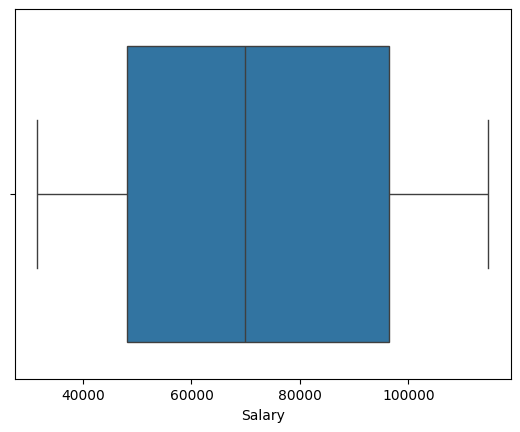

In [18]:
sns.boxplot(x= "Salary",data =dataset)
plt.show()

###### Removing outlier by Direct Method

In [19]:
# Direct Method
min_range = dataset["Salary"].mean() - (3 *dataset["Salary"].std())
max_range = dataset["Salary"].mean() + (3 *dataset["Salary"].std())


In [20]:
min_range, max_range

(np.float64(-6698.408520517114), np.float64(150948.79627561916))

In [22]:
new_data = dataset[dataset["Salary"]<=max_range]
new_data

,EmployeeID,Name,Department,Age,Salary,JoiningDate,PerformanceScore,Gender,Marital Status,Experience(Years),Education,Location
1,1002,Employee_2,IT,51.0,106209.0,22-08-2017,4.5,Female,NaN,10,PhD,Chennai
2,1003,Employee_3,Marketing,52.0,39084.0,29-10-2016,2.7,Male,Single,11,High School,Chennai
3,1004,Employee_4,HR,57.0,62214.0,28-09-2015,4.6,Female,Single,1,Master,Bangalore
4,1005,Employee_5,IT,36.0,114659.0,11-03-2020,3.4,Male,Single,10,Bachelor,Mumbai
5,1006,Employee_6,Marketing,50.0,37690.0,24-07-2019,4.2,Male,Married,10,Master,Chennai
...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,Employee_96,Sales,34.0,69572.0,06-01-2015,2.4,Male,Single,6,Master,Chennai
96,1097,Employee_97,Marketing,29.0,66568.0,21-03-2019,3.5,Male,Married,7,High School,Hyderabad
97,1098,Employee_98,HR,30.0,112522.0,15-01-2015,3.1,Female,Married,14,PhD,Hyderabad
98,1099,Employee_99,Finance,22.0,67827.0,01-05-2017,4.4,Female,Married,7,Bachelor,Chennai


<Axes: xlabel='Salary'>

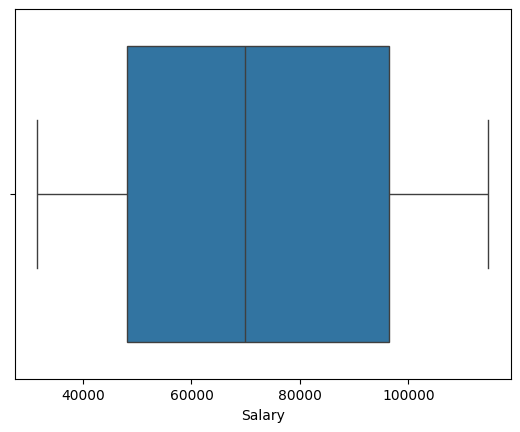

In [23]:
# boxplot of new dataset (checking for outliers)

sns.boxplot(x= "Salary",data =new_data)

#### Removing outlier using z score

In [25]:
z_score = (dataset["Salary"] - dataset["Salary"].mean())/(dataset["Salary"].std())

In [26]:
z_score

0          NaN
1     1.297218
2    -1.257537
3    -0.377217
4     1.618822
        ...   
95   -0.097174
96   -0.211505
97    1.537489
98   -0.163588
99    1.243783
Name: Salary, Length: 100, dtype: float64

In [28]:
# placing the Z score value in the original dataset
dataset["Z-Score"] = z_score

In [29]:
dataset

,EmployeeID,Name,Department,Age,Salary,JoiningDate,PerformanceScore,Gender,Marital Status,Experience(Years),Education,Location,Z-Score
0,1001,Employee_1,IT,55.0,NaN,01-02-2020,2.6,Male,NaN,6,PhD,Delhi,NaN
1,1002,Employee_2,IT,51.0,106209.0,22-08-2017,4.5,Female,NaN,10,PhD,Chennai,1.297218
2,1003,Employee_3,Marketing,52.0,39084.0,29-10-2016,2.7,Male,Single,11,High School,Chennai,-1.257537
3,1004,Employee_4,HR,57.0,62214.0,28-09-2015,4.6,Female,Single,1,Master,Bangalore,-0.377217
4,1005,Employee_5,IT,36.0,114659.0,11-03-2020,3.4,Male,Single,10,Bachelor,Mumbai,1.618822
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,Employee_96,Sales,34.0,69572.0,06-01-2015,2.4,Male,Single,6,Master,Chennai,-0.097174
96,1097,Employee_97,Marketing,29.0,66568.0,21-03-2019,3.5,Male,Married,7,High School,Hyderabad,-0.211505
97,1098,Employee_98,HR,30.0,112522.0,15-01-2015,3.1,Female,Married,14,PhD,Hyderabad,1.537489
98,1099,Employee_99,Finance,22.0,67827.0,01-05-2017,4.4,Female,Married,7,Bachelor,Chennai,-0.163588


In [30]:
# removing the outlier
dataset[dataset["Z-Score"]<3]

,EmployeeID,Name,Department,Age,Salary,JoiningDate,PerformanceScore,Gender,Marital Status,Experience(Years),Education,Location,Z-Score
1,1002,Employee_2,IT,51.0,106209.0,22-08-2017,4.5,Female,NaN,10,PhD,Chennai,1.297218
2,1003,Employee_3,Marketing,52.0,39084.0,29-10-2016,2.7,Male,Single,11,High School,Chennai,-1.257537
3,1004,Employee_4,HR,57.0,62214.0,28-09-2015,4.6,Female,Single,1,Master,Bangalore,-0.377217
4,1005,Employee_5,IT,36.0,114659.0,11-03-2020,3.4,Male,Single,10,Bachelor,Mumbai,1.618822
5,1006,Employee_6,Marketing,50.0,37690.0,24-07-2019,4.2,Male,Married,10,Master,Chennai,-1.310592
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,Employee_96,Sales,34.0,69572.0,06-01-2015,2.4,Male,Single,6,Master,Chennai,-0.097174
96,1097,Employee_97,Marketing,29.0,66568.0,21-03-2019,3.5,Male,Married,7,High School,Hyderabad,-0.211505
97,1098,Employee_98,HR,30.0,112522.0,15-01-2015,3.1,Female,Married,14,PhD,Hyderabad,1.537489
98,1099,Employee_99,Finance,22.0,67827.0,01-05-2017,4.4,Female,Married,7,Bachelor,Chennai,-0.163588
